# Predicción de Precios de Vivienda con SVM

Este notebook replica el proceso de carga, limpieza y preparación de datos del análisis principal, y agrega un modelo de Máquina de Soporte Vectorial (SVM) para la predicción de precios de viviendas en la CDMX.

## 1. Importación de Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Modelos y métricas
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

# Crear carpeta de visualizaciones
visualizations_dir = Path('visualizations')
visualizations_dir.mkdir(exist_ok=True)

print('Librerías importadas correctamente')

Librerías importadas correctamente


## 2. Carga del Dataset

In [3]:
# Cargar el archivo CSV
csv_path = Path('housing_data_CDMX_v2.csv')
df = pd.read_csv(csv_path)

# Información básica
print(f'Archivo cargado: {csv_path}')
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')
print(f'\nTipos de datos:')
print(df.info())

Archivo cargado: housing_data_CDMX_v2.csv
Filas: 18234
Columnas: 13

Tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 18234 entries, 0 to 18233
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_type               18234 non-null  str    
 1   places                      18234 non-null  str    
 2   lat-lon                     18234 non-null  str    
 3   price                       18234 non-null  float64
 4   currency                    18234 non-null  str    
 5   price_aprox_local_currency  18234 non-null  float64
 6   price_aprox_usd             18234 non-null  float64
 7   surface_total_in_m2         18234 non-null  float64
 8   surface_covered_in_m2       18234 non-null  float64
 9   price_usd_per_m2            18234 non-null  float64
 10  price_per_m2                18234 non-null  float64
 11  lat                         18234 non-null  float64
 12  lon           

## 3. Limpieza y Preparación de Datos

In [4]:
# Eliminación de columnas innecesarias
columns_to_drop = [
    'currency',
    'price_aprox_usd',
    'price_usd_per_m2',
    'lat-lon',
    'price_aprox_local_currency',
    'places'
]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print('Columnas después de eliminar innecesarias:')
print(list(df.columns))

Columnas después de eliminar innecesarias:
['property_type', 'price', 'surface_total_in_m2', 'surface_covered_in_m2', 'price_per_m2', 'lat', 'lon']


In [5]:
# Eliminación de outliers usando el método del rango intercuartílico (IQR)
numeric_cols_for_outliers = ['price', 'surface_total_in_m2', 'surface_covered_in_m2']

print('Eliminación de outliers:')
for col in numeric_cols_for_outliers:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        count_before = len(df)
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)].copy()
        count_after = len(df)
        print(f'{col}: {count_before - count_after} outliers eliminados')

print(f'\nTamaño del dataset después de limpiar outliers: {df.shape}')

Eliminación de outliers:
price: 1538 outliers eliminados
surface_total_in_m2: 1543 outliers eliminados
surface_covered_in_m2: 1218 outliers eliminados

Tamaño del dataset después de limpiar outliers: (13935, 7)


In [6]:
# Detección de valores faltantes y duplicados
missing_values = df.isnull().sum()
duplicates = df.duplicated().sum()

print('Valores faltantes:')
print(missing_values[missing_values > 0])
print(f'\nDuplicados: {duplicates}')

# Eliminar duplicados si existen
if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Duplicados eliminados')

Valores faltantes:
Series([], dtype: int64)

Duplicados: 2972
Duplicados eliminados


In [7]:
# One-hot encoding para property_type
if 'property_type' in df.columns:
    property_type_dummies = pd.get_dummies(df['property_type'], prefix='property_type', dtype=int)
    df = pd.concat([df, property_type_dummies], axis=1)
    property_type_dummy_cols = list(property_type_dummies.columns)
    print('Columnas dummy creadas para property_type:')
    print(property_type_dummy_cols)
else:
    property_type_dummy_cols = [col for col in df.columns if col.startswith('property_type_')]
    print('Usando columnas dummy existentes')

print(f'\nDataset preparado con forma: {df.shape}')

Columnas dummy creadas para property_type:
['property_type_PH', 'property_type_apartment', 'property_type_house', 'property_type_store']

Dataset preparado con forma: (10963, 11)


## 4. Modelo de Máquina de Soporte Vectorial (SVM)

La Máquina de Soporte Vectorial (SVM) es un algoritmo poderoso que busca encontrar el hiperplano óptimo que maximiza el margen entre puntos de diferentes clases. Para regresión, utilizamos SVR (Support Vector Regressor), que extiende SVM para problemas de regresión.

In [8]:
# Preparación de características y variable objetivo
df_model = df.copy()

feature_cols = [
    'surface_total_in_m2',
    'surface_covered_in_m2',
    'lat',
    'lon',
    'property_type_PH',
    'property_type_house',
    'property_type_apartment',
    'property_type_store'
]

target_col = 'price'
model_df = df_model[feature_cols + [target_col]].dropna()

X = model_df[feature_cols].astype(float)
y = model_df[target_col].astype(float)

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Conjunto de prueba: {X_test.shape[0]} muestras')

Conjunto de entrenamiento: 8770 muestras
Conjunto de prueba: 2193 muestras


In [9]:
# SVM requiere que los datos estén escalados/normalizados
# Esto es crucial para el desempeño del algoritmo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Datos escalados correctamente')
print(f'Rango de valores después del escalado: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]')

Datos escalados correctamente
Rango de valores después del escalado: [-8.36, 41.87]


In [10]:
# Entrenamiento de un modelo SVM básico con kernel RBF
# El kernel RBF es útil para problemas no lineales complejos
print('Entrenando modelo SVM con kernel RBF...')

svm_model = SVR(kernel='rbf', C=100000, epsilon=0.1, gamma='scale')
svm_model.fit(X_train_scaled, y_train)

print('Modelo entrenado correctamente')

Entrenando modelo SVM con kernel RBF...
Modelo entrenado correctamente


In [11]:
# Evaluación del modelo SVM
svm_pred = svm_model.predict(X_test_scaled)

svm_mae = mean_absolute_error(y_test, svm_pred)
svm_mse = mean_squared_error(y_test, svm_pred)
svm_rmse = np.sqrt(svm_mse)
svm_r2 = r2_score(y_test, svm_pred)

print('\n' + '='*50)
print('RESULTADOS DEL MODELO SVM')
print('='*50)
print(f'R² Score: {svm_r2:.4f}')
print(f'MAE (Error Absoluto Medio): ${svm_mae:,.2f}')
print(f'MSE (Error Cuadrático Medio): ${svm_mse:,.2f}')
print(f'RMSE (Raíz del Error Cuadrático Medio): ${svm_rmse:,.2f}')
print('='*50)


RESULTADOS DEL MODELO SVM
R² Score: 0.3922
MAE (Error Absoluto Medio): $916,890.55
MSE (Error Cuadrático Medio): $1,736,160,630,815.60
RMSE (Raíz del Error Cuadrático Medio): $1,317,634.48


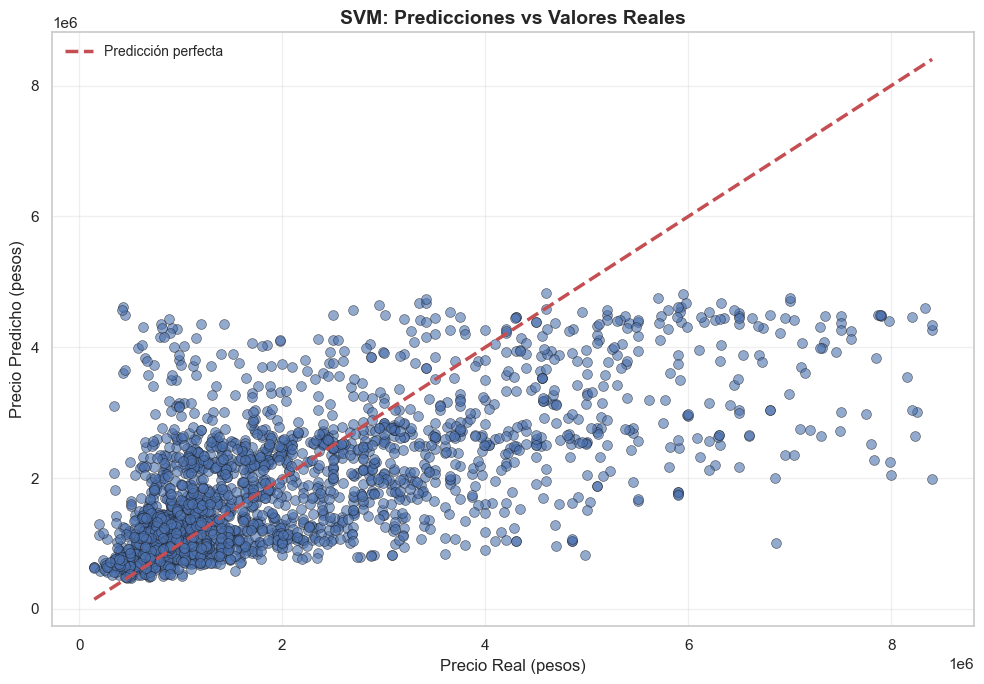

In [12]:
# Visualización: Predicciones vs Valores Reales
plt.figure(figsize=(10, 7))
plt.scatter(y_test, svm_pred, alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2.5, label='Predicción perfecta')
plt.xlabel('Precio Real (pesos)', fontsize=12)
plt.ylabel('Precio Predicho (pesos)', fontsize=12)
plt.title('SVM: Predicciones vs Valores Reales', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(visualizations_dir / '07_svm_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

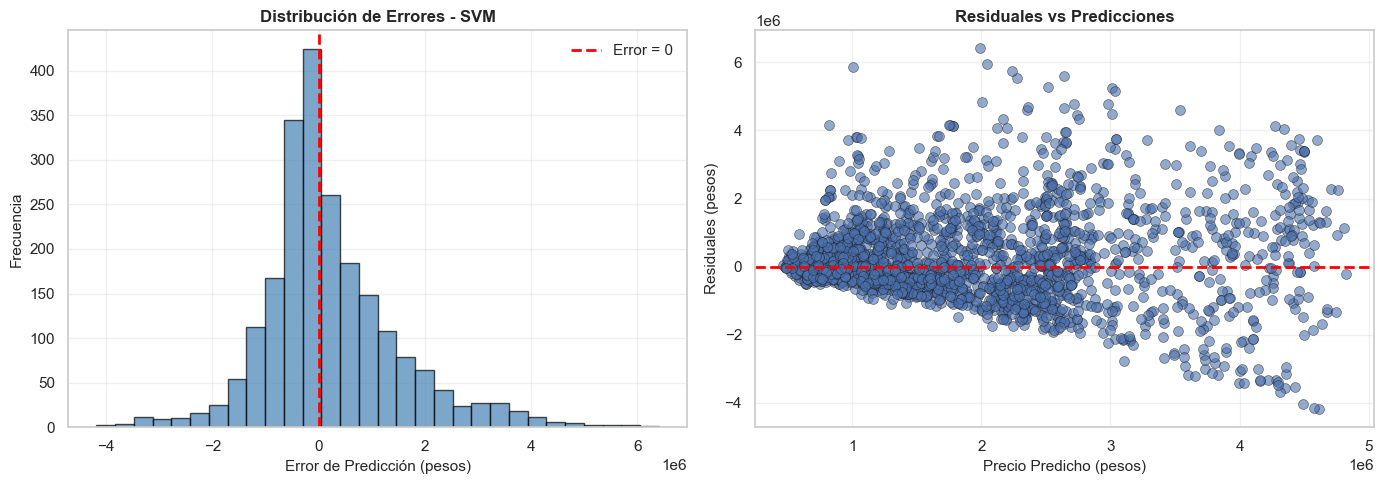

In [13]:
# Análisis de residuales (errores)
svm_residuals = y_test - svm_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de residuales
axes[0].hist(svm_residuals, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Error = 0')
axes[0].set_xlabel('Error de Predicción (pesos)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de Errores - SVM', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica de residuales vs predicciones
axes[1].scatter(svm_pred, svm_residuals, alpha=0.6, s=50, edgecolors='k', linewidth=0.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Precio Predicho (pesos)', fontsize=11)
axes[1].set_ylabel('Residuales (pesos)', fontsize=11)
axes[1].set_title('Residuales vs Predicciones', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(visualizations_dir / '08_svm_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Optimización de Hiperparámetros con Grid Search

In [ ]:
# Búsqueda de los mejores hiperparámetros para SVM
print('Realizando Grid Search para optimizar hiperparámetros...')
print('Esto puede tomar algunos minutos...')

param_grid = {
    'C': [1000, 10000, 100000],
    'epsilon': [0.01, 0.1, 1],
    'gamma': ['scale', 'auto', 0.001, 0.01]
}

# Usar validación cruzada de 5 pliegues
grid_search = GridSearchCV(
    SVR(kernel='rbf'),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f'\nMejores parámetros: {grid_search.best_params_}')
print(f'Mejor puntuación (R² en validación cruzada): {grid_search.best_score_:.4f}')

Realizando Grid Search para optimizar hiperparámetros...
Esto puede tomar algunos minutos...


In [ ]:
# Evaluar el modelo optimizado
best_svm_model = grid_search.best_estimator_
best_svm_pred = best_svm_model.predict(X_test_scaled)

best_svm_mae = mean_absolute_error(y_test, best_svm_pred)
best_svm_mse = mean_squared_error(y_test, best_svm_pred)
best_svm_rmse = np.sqrt(best_svm_mse)
best_svm_r2 = r2_score(y_test, best_svm_pred)

print('\n' + '='*50)
print('RESULTADOS DEL MODELO SVM OPTIMIZADO')
print('='*50)
print(f'R² Score: {best_svm_r2:.4f}')
print(f'MAE: ${best_svm_mae:,.2f}')
print(f'RMSE: ${best_svm_rmse:,.2f}')
print('='*50)

# Comparación de mejora
improvement = ((best_svm_r2 - svm_r2) / svm_r2) * 100
print(f'\nMejora en R² después de optimizar: {improvement:+.2f}%')

In [ ]:
# Visualización del modelo optimizado
plt.figure(figsize=(10, 7))
plt.scatter(y_test, best_svm_pred, alpha=0.6, s=50, color='darkgreen', edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2.5, label='Predicción perfecta')
plt.xlabel('Precio Real (pesos)', fontsize=12)
plt.ylabel('Precio Predicho (pesos)', fontsize=12)
plt.title('SVM Optimizado: Predicciones vs Valores Reales', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(visualizations_dir / '09_svm_optimized_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Comparación de Resultados

In [ ]:
# Crear tabla comparativa
comparison_df = pd.DataFrame({
    'Modelo': ['SVM (Básico)', 'SVM (Optimizado)'],
    'R² Score': [svm_r2, best_svm_r2],
    'MAE': [svm_mae, best_svm_mae],
    'RMSE': [svm_rmse, best_svm_rmse],
})

print('\nComparación de Modelos SVM:')
print(comparison_df.to_string(index=False))

In [ ]:
# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['SVM Básico', 'SVM Optimizado']
r2_scores = [svm_r2, best_svm_r2]
mae_values = [svm_mae, best_svm_mae]
rmse_values = [svm_rmse, best_svm_rmse]

# R² Score
axes[0].bar(models, r2_scores, color=['steelblue', 'darkgreen'], alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('R² Score', fontsize=11)
axes[0].set_title('Comparación de R² Score', fontsize=12, fontweight='bold')
axes[0].set_ylim([0, 1])
for i, v in enumerate(r2_scores):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# MAE
axes[1].bar(models, mae_values, color=['steelblue', 'darkgreen'], alpha=0.7, edgecolor='black', linewidth=2)
axes[1].set_ylabel('MAE (pesos)', fontsize=11)
axes[1].set_title('Comparación de MAE', fontsize=12, fontweight='bold')
for i, v in enumerate(mae_values):
    axes[1].text(i, v + 10000, f'${v/1000:.0f}K', ha='center', fontweight='bold')

# RMSE
axes[2].bar(models, rmse_values, color=['steelblue', 'darkgreen'], alpha=0.7, edgecolor='black', linewidth=2)
axes[2].set_ylabel('RMSE (pesos)', fontsize=11)
axes[2].set_title('Comparación de RMSE', fontsize=12, fontweight='bold')
for i, v in enumerate(rmse_values):
    axes[2].text(i, v + 20000, f'${v/1000:.0f}K', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(visualizations_dir / '10_svm_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Conclusiones del Modelo SVM

### Ventajas de SVM para este problema:
1. **Efectividad en espacios de alta dimensión:** Excelente para datasets con muchas características
2. **Flexibilidad con kernels:** Permite capturar relaciones no lineales complejas
3. **Robustez:** Menos propenso al overfitting comparado con otros algoritmos
4. **Margen máximo:** Busca generalizar bien a datos no vistos

### Desafíos encontrados:
1. **Escalado crítico:** SVM es muy sensible a la escala de las características
2. **Tiempo de entrenamiento:** Puede ser lento con datasets grandes
3. **Selección de hiperparámetros:** Requiere tuning cuidadoso para obtener buen desempeño

### Comparación con otros modelos del proyecto:
- **vs Regresión Lineal:** SVM captura relaciones no lineales mejor
- **vs Random Forest:** SVM puede ser más eficiente en memoria pero requiere más tuning
- **vs Regresión Polinomial:** SVM ofrece más flexibilidad con kernels